In [1]:
import urllib
import numpy as np
import os
import netCDF4 as nc
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sunpy.net import Fido, attrs as a
import astropy.units as u
from astropy.io import fits
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import drms

import sys
folder_path = '/Users/coletamburri/Desktop/DKIST_Code/Flare_Patrol_Analysis/gbm_data_tools-1.1.1/' 

# Or use a relative path if the folder is in a fixed location relative to the notebook
# Example: a 'src' folder one level up from the current notebook's directory
# folder_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'src'))

# Add the folder to the system path
if folder_path not in sys.path:
    sys.path.append(folder_path)
    
import gbm
from gbm.plot import Spectrum

from gbm import test_data_dir
# import the CTIME and CSPEC data classes
from gbm.data import Ctime, Cspec
from gbm.binning.binned import rebin_by_time

/Users/coletamburri/Desktop/DKIST_Code/Flare_Patrol_Analysis/gbm_data_tools-1.1.1/gbm/plot/lal_post_subs.py:184: UserWarning: Basemap not installed. Some functionality not available.
  warnings.warn('Basemap not installed. Some functionality not available.')


In [2]:
def datenum_to_datetime(datenum):
    """
    Convert Matlab datenum into Python datetime.
    :param datenum: Date in datenum format
    :return:        Datetime object corresponding to datenum.
    """
    days = datenum % 1
    hours = days % 1 * 24
    minutes = hours % 1 * 60
    seconds = minutes % 1 * 60
    return datetime.fromordinal(int(datenum)) \
           + timedelta(days=int(days)) \
           + timedelta(hours=int(hours)) \
           + timedelta(minutes=int(minutes)) \
           + timedelta(seconds=round(seconds)) \
           - timedelta(days=366)



In [3]:
# ViSP - H-beta
filehb = '/Users/coletamburri/Desktop/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/hb_lc.npz'
hbdat = np.load(filehb)

# ViSP - H-eps
filehe = '/Users/coletamburri/Desktop/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/heps_lc.npz'
hedat = np.load(filehe)

# ViSP - Ca II
filecaii = '/Users/coletamburri/Desktop/11_Aug_2024_Cclass_Flare/Processed_ViSP_VBI_11Aug2024/caiih_lc.npz'
caiidat = np.load(filecaii)

In [4]:
times_hb = hbdat['times']
lc_hb = hbdat['lc']

times_heps = hedat['times']
lc_heps = hedat['lc']

times_caii = caiidat['times']
lc_caii = caiidat['lc']



In [5]:
startind = 83

lc_hb2 = []
times_hb2 = []
for i in range(14):
    scanmean = np.mean(lc_hb[startind+(91*i):startind+(91*(i+1)),:])-0.12 #arbitrary scale factor to make pretty
    print(scanmean)
    lc_hb2.append(scanmean)
    times_hb2.append(times_hb[startind+(91*i)+40])

lc_heps2 = []
times_heps2 = []
for i in range(14):
    scanmean = np.mean(lc_heps[startind+(91*i):startind+(91*(i+1)),:])
    print(scanmean)
    lc_heps2.append(scanmean)
    times_heps2.append(times_heps[startind+(91*i)+40])

lc_caii2 = []
times_caii2 = []
for i in range(14):
    scanmean = np.mean(lc_caii[startind+(91*i):startind+(91*(i+1)),:])+0.01
    print(scanmean)
    lc_caii2.append(scanmean)
    times_caii2.append(times_caii[startind+(91*i)+40])

0.36354822
0.3639426
0.36389622
0.368231
0.37355766
0.37150204
0.3693931
0.37143707
0.37135
0.37066808
0.3704342
0.3712443
0.36988735
0.3695942
0.34988743
0.35055998
0.35183805
0.36049846
0.36938134
0.36758676
0.3653124
0.3686811
0.3689814
0.36801228
0.36712888
0.3677243
0.36527938
0.36378396
0.32422435
0.32582584
0.32867876
0.34240147
0.3580502
0.35364679
0.3508378
0.354432
0.35447153
0.35375404
0.3535853
0.35461912
0.35112944
0.34809


2026-04-22 14:57:41 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-22 14:57:41 - matplotlib.category - INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


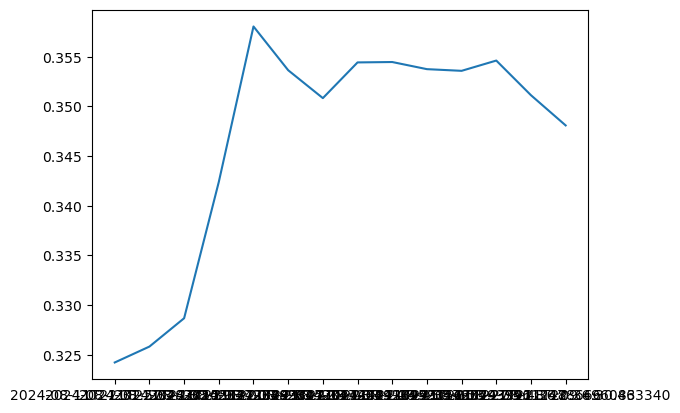

In [6]:
plt.plot(times_caii2,lc_caii2)

In [7]:
times_heps2

[np.str_('2024-08-11T22:31:57.487715'),
 np.str_('2024-08-11T22:32:18.505132'),
 np.str_('2024-08-11T22:32:39.472389'),
 np.str_('2024-08-11T22:33:00.489807'),
 np.str_('2024-08-11T22:33:21.457064'),
 np.str_('2024-08-11T22:33:42.474481'),
 np.str_('2024-08-11T22:34:03.491899'),
 np.str_('2024-08-11T22:34:24.459156'),
 np.str_('2024-08-11T22:34:45.476574'),
 np.str_('2024-08-11T22:35:06.493991'),
 np.str_('2024-08-11T22:35:27.461248'),
 np.str_('2024-08-11T22:35:48.478666'),
 np.str_('2024-08-11T22:36:09.496083'),
 np.str_('2024-08-11T22:36:30.463340')]

In [8]:
times_hb[-1]

np.str_('2024-08-11T22:36:50.527701')

In [9]:
t_visp = np.arange(datetime(2024,8,11,22,31,57),
              datetime(2024,8,11,22,36,31), 
              timedelta(seconds=21)).astype(datetime)
len(t_hb)

NameError: name 't_hb' is not defined

In [10]:
#download aia data
results = Fido.search(a.Time("2024/8/11 22:00:00", "2024/8/11 23:00:00"),
                     a.Instrument.aia,a.Wavelength(304*u.angstrom))

client = drms.Client()
keys = [
    "T_REC",
    "T_OBS",
    "DATAMIN",
    "DATAMAX",
    "DATAMEAN",
    "DATARMS",
    "DATAMEDN",
    "DATASKEW",
    "DATAKURT",
    "DATA",
    "QUALITY",
]

print("Querying series info...")
series_info = client.info("aia.lev1_euv_12s")
series_info_lev1 = client.info("aia.lev1")


Querying series info...


In [11]:
qstr = "aia.lev1_euv_12s[2024-08-11T22:00:01Z/1h@12s][304]"

# Get keyword values for the selected timespan and wavelength
print(f"Querying keyword data...\n -> {qstr}")
result = client.query(qstr, key=keys)
print(f" -> {len(result)} lines retrieved.")

# Only use entries with QUALITY==0
result = result[result.QUALITY == 0]
print(f" -> {len(result)} lines after QUALITY selection.")

# Convert T_REC strings to datetime and use it as index for the series
result.index = drms.to_datetime(result.T_REC)

Querying keyword data...
 -> aia.lev1_euv_12s[2024-08-11T22:00:01Z/1h@12s][304]
 -> 300 lines retrieved.
 -> 300 lines after QUALITY selection.


In [12]:
# sci_xrsf-l2-avg1m_g17_d20220819_v2-2-0.nc	
# new_x = "/Users/coletamburri/Desktop/19_December_2022.nc"
# #x = 'https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes16/l2/data/xrsf-l2-flx1s_science/2024/08/sci_xrsf-l2-flx1s_g16_d20240827_v2-2-0.nc	'
# x = 'https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/goes16/l2/data/xrsf-l2-flx1s_science/2022/12/sci_xrsf-l2-flx1s_g16_d20221228_v2-2-0.nc'
# urllib.request.urlretrieve(x, new_x)
fn = "/Users/coletamburri/Desktop/DKIST_Data_Tools_misc/GOES_NETCDF_Flare_Files/11_August_2024.nc"
ds = nc.Dataset(fn)

In [13]:
t=ds['time']
ds['xrsa1_flux']

t = np.arange(datetime(2024,8,11,0,0,0),
              datetime(2024,8,12,0,0,0), 
              timedelta(seconds=1)).astype(datetime)

t2 = np.arange(datetime(2024,8,11,22,0,0),
              datetime(2024,8,11,23,0,0), 
              timedelta(seconds=12)).astype(datetime)

In [33]:
loadvbilc = np.load('/Users/coletamburri/Desktop/vbi_lc_extended.npz',allow_pickle='True')
#timesvbi=loadvbilc['times']
lcvbi=loadvbilc['lc']
# t3 = np.arange(datetime(2024,8,11,22,31,26),
#               datetime(2024,8,11,22,38,57), 
#               timedelta(seconds=2.666)).astype(datetime)

#for extended
t3 = np.arange(datetime(2024,8,11,22,25,39),
              datetime(2024,8,11,22,38,57), 
              timedelta(seconds=2.666)).astype(datetime)

In [16]:
specdata = '/Users/coletamburri/Desktop/11_Aug_2024_Cclass_Flare/11Aug_Fermi/glg_cspec_n5_240811_v00.pha'

In [17]:
cspec = Cspec.open(specdata)
t4 = np.arange(datetime(2024,8,11,0,0,0),
              datetime(2024,8,11,23,59,59), 
              timedelta(seconds=4.096)).astype(datetime)

/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_46611/347469137.py:6: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(energy_sliced0.rates))
/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_46611/347469137.py:7: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(energy_sliced1.rates))
/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_46611/347469137.py:8: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(energy_sliced2.rates))


(2.0, 4.5)

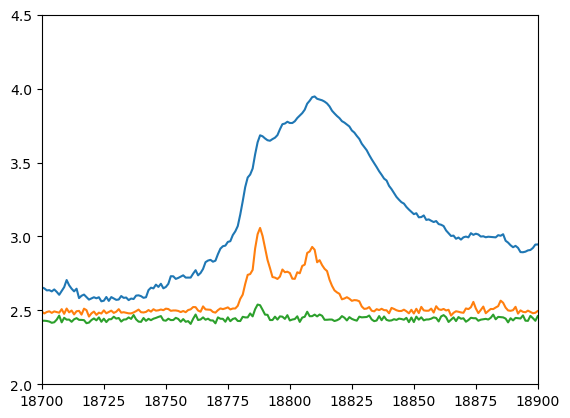

In [18]:
energy_sliced0 = cspec.slice_energy((4,15)).to_lightcurve()

energy_sliced1 = cspec.slice_energy((15,25)).to_lightcurve()

energy_sliced2 = cspec.slice_energy((25,50)).to_lightcurve()
plt.plot(np.log10(energy_sliced0.rates))
plt.plot(np.log10(energy_sliced1.rates))
plt.plot(np.log10(energy_sliced2.rates))
plt.xlim([18700,18900])
plt.ylim([2,4.5])
#plt.xlim([datetime(2024, 8, 11, 21, 0, 11, 424000),datetime(2024, 8, 11, 23, 40, 11, 424000)])

In [19]:


# 1. Define the specific starting date
start_date = datetime(2001, 1, 1, 0, 0, 0) # Year, Month, Day, Hour, Minute, Second

# 2. Define the duration in seconds as a timedelta object
t4=[]
for i in range(len(cspec.data.time_centroids)):

    elapsed_seconds = cspec.data.time_centroids[i]
    time_delta = timedelta(seconds=elapsed_seconds)
    
    # 3. Add the timedelta to the start date to get the resulting datetime
    result_datetime = start_date + time_delta
    t4.append(result_datetime)

In [32]:
# fried
fried = np.load('/Users/coletamburri/Desktop/11aug2024_fried.npz')

friedvbi=fried['fried']
# t3 = np.arange(datetime(2024,8,11,22,31,26),
#               datetime(2024,8,11,22,38,57), 
#               timedelta(seconds=2.666)).astype(datetime)

#for extended
t11 = np.arange(datetime(2024,8,11,22,23,34),
              datetime(2024,8,11,23,16,14), 
              timedelta(seconds=2.666)).astype(datetime)

/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_46611/3258835728.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  lns1 = ax.plot(t,np.array(ds['xrsb1_flux']),linewidth=6,color='k',label=r'XRS 1-8$\AA$')
/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_46611/3258835728.py:5: RuntimeWarning: divide by zero encountered in log10
  lns4 = ax4.plot(t4,np.log10(energy_sliced0.rates),c='#77AADD',label='GBM 4-15 keV',linewidth=6,linestyle='solid')
/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_46611/3258835728.py:6: RuntimeWarning: divide by zero encountered in log10
  lns5 = ax4.plot(t4,np.log10(energy_sliced1.rates),c='#DDCC77',label='GBM 15-25 keV',linewidth=6,linestyle='solid')
/var/folders/_1/p_v_pt7912z2pqq5nrvwvhlc0000gn/T/ipykernel_46611/3258835728.py:7: RuntimeWarning: divide by zero encountered in log10
  lns6 = ax4.plot(t4,np

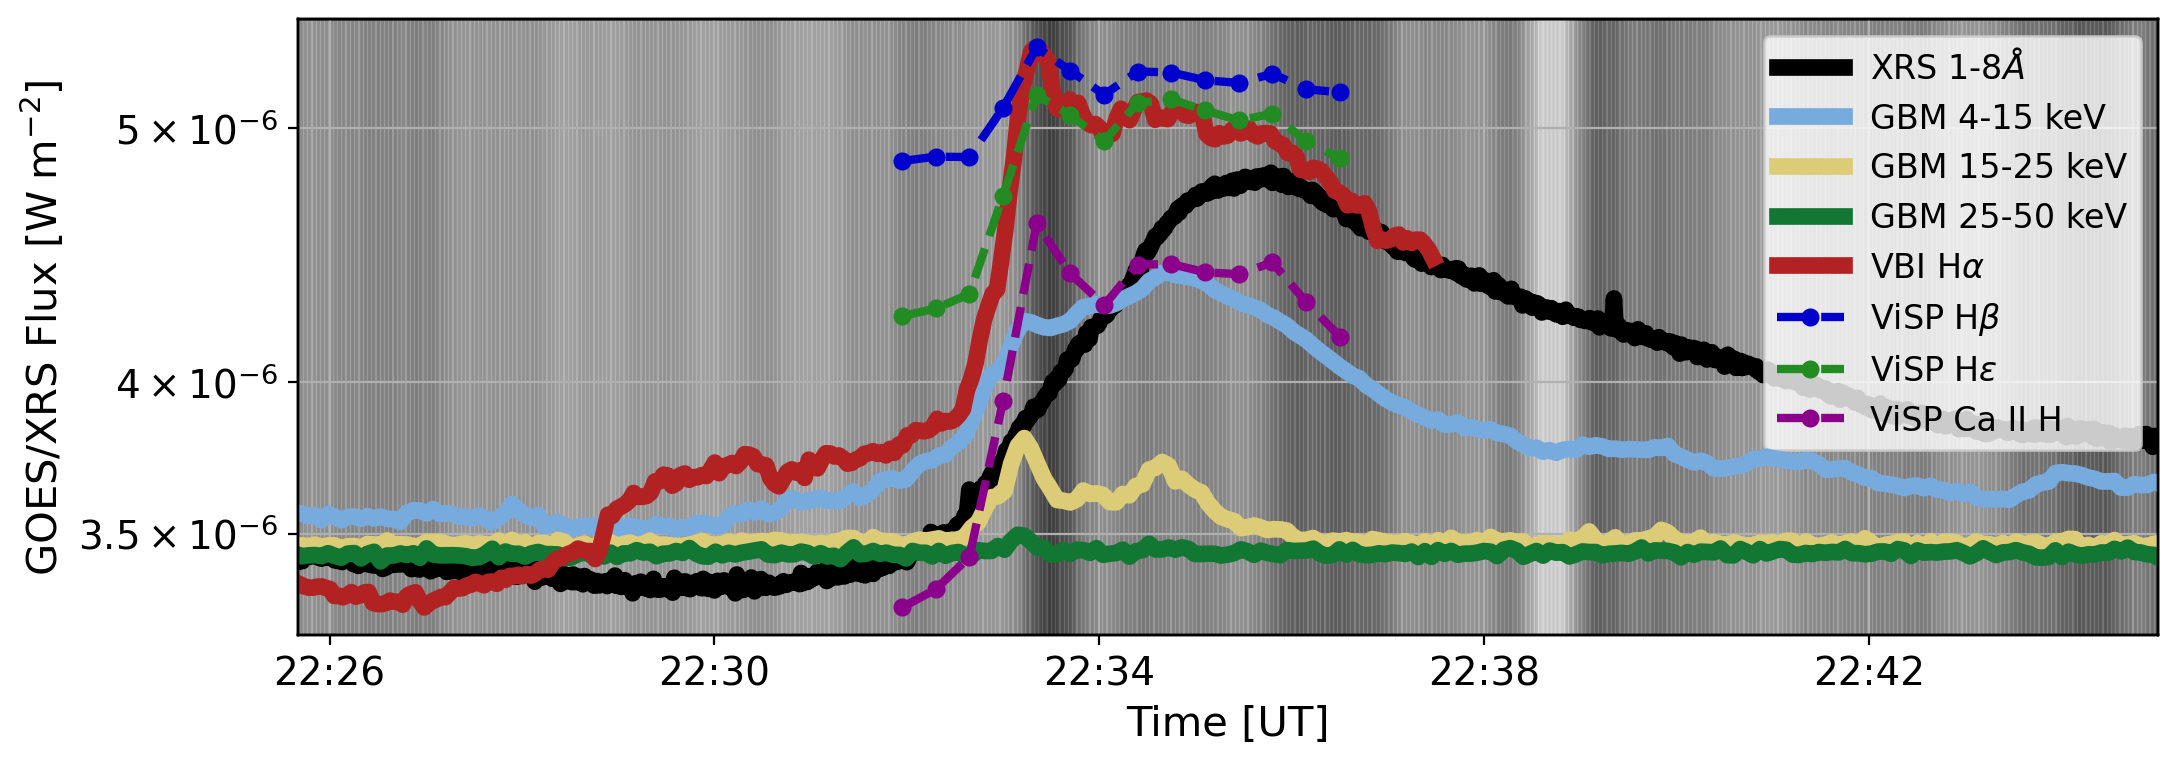

In [86]:
fig,ax = plt.subplots(figsize=(12,4),dpi=200)
lns1 = ax.plot(t,np.array(ds['xrsb1_flux']),linewidth=6,color='k',label=r'XRS 1-8$\AA$')
ax2=ax.twinx()
ax4=ax.twinx()
lns4 = ax4.plot(t4,np.log10(energy_sliced0.rates),c='#77AADD',label='GBM 4-15 keV',linewidth=6,linestyle='solid')
lns5 = ax4.plot(t4,np.log10(energy_sliced1.rates),c='#DDCC77',label='GBM 15-25 keV',linewidth=6,linestyle='solid')
lns6 = ax4.plot(t4,np.log10(energy_sliced2.rates),c='#117733',label='GBM 25-50 keV',linewidth=6,linestyle='solid')
ax3=ax.twinx()
lns3=ax3.plot(t3[:267],lcvbi[:267],c='firebrick',label=r'VBI H$\alpha$',linewidth=6)
ax5=ax.twinx()
lns7 = ax5.plot(t_visp,lc_hb2,c='mediumblue',label=r'ViSP H$\beta$',linewidth=3,linestyle='dashed',marker='.',markersize=11)
lns8 = ax5.plot(t_visp,lc_heps2,c='forestgreen',label=r'ViSP H$\epsilon$',linewidth=3,linestyle='dashed',marker='.',markersize=11)

lns9 = ax5.plot(t_visp,lc_caii2,c='darkmagenta',label=r'ViSP Ca II H',linewidth=3,linestyle='dashed',marker='.',markersize=11)
#ax11 = ax.twinx()
#lns10 = ax11.plot(t11,friedvbi,c='violet',label=r'Fried parameter [$r_0$]',linewidth=3,linestyle='dashed',marker='.',markersize=11)


fried_norm = (friedvbi - (np.min(friedvbi)-2)) / (np.max(friedvbi)+10- (np.min(friedvbi)-2))

for i in range(len(t11) - 6):
    ax.axvspan(t11[i], t11[i+6],
                    color='black', 
                    alpha=fried_norm[i]*0.3, 
                    edgecolor='palegreen')



ax4.set_ylim([2,5.3])

lns = lns1+lns4+lns5+lns6+lns3+lns7+lns8+lns9


labs = [l.get_label() for l in lns]
ax2.legend(lns, labs,loc="upper right",fontsize=12)
ax.set_ylabel(r'GOES/XRS Flux [$\text{W}\;\text{m}^{-2}$]',fontsize=15)
ax3.set_yticks([])
ax4.set_yticks([])
ax5.set_yticks([])
#ax6.set_yticks([])
#ax7.set_yticks([])
ax.set_yscale("log")


ax.set_xlabel('Time [UT]',fontsize=15)
ax.set_xlim([datetime(2024,8,11,22,25,40),datetime(2024,8,11,22,45,00)])
ax.set_ylim([3.2e-6,5.5e-6])

ax.set_xticks([datetime(2024,8,11,22,26,0),datetime(2024,8,11,22,30,0),datetime(2024,8,11,22,34,00),datetime(2024,8,11,22,38,00),datetime(2024,8,11,22,42,00)],['22:26','22:30','22:34','22:38','22:42'])
ax2.set_yticks([])
ax.grid()
ax.set_yticks([3.5e-6,4e-6,5e-6])

ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

#ax.axvline(datetime(2024,8,11,22,33,12))

#ax.axvline(datetime(2024,8,11,22,35,45))

